In [1]:
import pandas as pd
import json
import yaml
import seaborn as sns
from pathlib import Path

In [2]:
folder = Path('..', 'outputs', '000.experiments')

experiments = [ p for p in folder.iterdir()
                if p.is_dir() and Path(p, 'eval_results.json').exists() ]

for p in experiments: print(p.name)

000308f618ba50bfc31c9fda75f9935a
f7689c45e024849dfa5c636288428c54
44645507ca558056b0317e6590590d09
06336ee064c31b88fefba9ee1331891a
ec84c53d17074d7b7deca1377e975e6c
06969995032f0981c2f8d365ff320b38
8af782415539b8c293773d76f416f182
c1ee6f9cf5f64008ef0eb22fd19615c0
1dc0573e753d378332febf8f80833f63
a51664adf5f01efc57493dc842ea6fb3
effcc5863878322553fe76f4fd0b5c6e
e0ac44754ab521f71ce9b0f596f6cd6b
f5a13abdd1bbeacdb7d79e04b78a3a2c
4603bc79974de5c5fa79029fe7ffa190
a983a72178c8a879c45b306da23d984f


In [3]:
def get_params(dir):
    params_file = Path(dir, 'parameters.yaml')
    parameters = yaml.safe_load(params_file.read_text())
    # parameters['folder'] = dir.name
    return parameters

def get_eval_results(dir):
    eval_file = Path(dir, 'eval_results.json')
    eval_results = json.loads(eval_file.read_text())
    eval_results['folder'] = dir.name
    return eval_results

df_params = pd.DataFrame([ get_params(p) for p in experiments ])
df_results = pd.DataFrame([ get_eval_results(p) for p in experiments])

df = pd.merge(df_params, df_results, left_on='_hash_id', right_on='folder')

teacher_keys = df['teachers_keys'].loc[0] # ['t5', 'llama']

df = pd.concat([
    df,
    df['teachers_weights'].apply(pd.Series, index=teacher_keys)
], axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   _hash_id                 15 non-null     object 
 1   _timestamp               15 non-null     object 
 2   batch_size               15 non-null     int64  
 3   bf16                     15 non-null     bool   
 4   dataset                  15 non-null     object 
 5   eval_steps               15 non-null     int64  
 6   from_pretrained          15 non-null     object 
 7   generation_max_length    15 non-null     int64  
 8   grad_steps               15 non-null     int64  
 9   local_rank               15 non-null     int64  
 10  logging_strategy         15 non-null     object 
 11  lr                       15 non-null     float64
 12  max_input_length         15 non-null     int64  
 13  max_steps                15 non-null     int64  
 14  model_id                 15 

In [5]:
# select = (df['t5'] == 1.0)  & (df['llama'] == 1.0)

# df[select]

In [6]:
df[
    ['dataset', 'teachers_weights', 'eval_accuracy', 'eval_token_accuracy']
].sort_values(by='eval_accuracy', ascending=False)

,dataset,teachers_weights,eval_accuracy,eval_token_accuracy
2,bioasq,"[1.0, 1.0]",0.894309,0.850000
6,bioasq,"[2.0, 2.0]",0.894309,0.850000
5,pubmedqa,"[1.0, 1.0]",0.700000,0.850000
0,obqa,"[2.0, 2.0]",0.694000,0.381091
14,piqa,"[1.0, 1.0]",0.690968,0.017628
7,pubmedqa,"[2.0, 2.0]",0.690000,0.850000
8,obqa,"[0.5, 0.5]",0.690000,0.381455
10,obqa,"[1.0, 1.0]",0.684000,0.380909
11,piqa,"[2.0, 2.0]",0.683351,0.017802
9,riddle,"[1.0, 1.0]",0.664706,0.756078


## Resultados do *paper* para **T5-large**
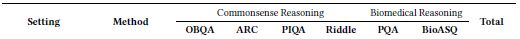 <br>
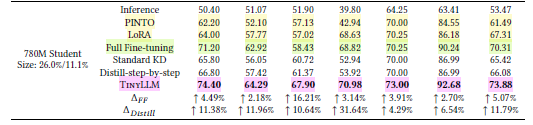

In [7]:
table = ( df[ ['_hash_id', 'dataset', 'teachers_weights', 'max_steps', 'eval_accuracy', 'eval_token_accuracy'] ]
         .loc[lambda x: x['max_steps']  == 10_000 ]
         .assign(teachers_weights=df['teachers_weights'].apply(lambda x: x[0] if x else None))
         .loc[lambda x: x['teachers_weights'] > 0.5]
         .sort_values(by=['dataset', 'teachers_weights'], ascending=[False, True])
         .reset_index(drop=True)
        )

table

,_hash_id,dataset,teachers_weights,max_steps,eval_accuracy,eval_token_accuracy
0,a51664adf5f01efc57493dc842ea6fb3,riddle,1.0,10000,0.664706,0.756078
1,f7689c45e024849dfa5c636288428c54,riddle,2.0,10000,0.650980,0.252700
2,06969995032f0981c2f8d365ff320b38,pubmedqa,1.0,10000,0.700000,0.850000
3,c1ee6f9cf5f64008ef0eb22fd19615c0,pubmedqa,2.0,10000,0.690000,0.850000
4,a983a72178c8a879c45b306da23d984f,piqa,1.0,10000,0.690968,0.017628
5,e0ac44754ab521f71ce9b0f596f6cd6b,piqa,2.0,10000,0.683351,0.017802
6,effcc5863878322553fe76f4fd0b5c6e,obqa,1.0,10000,0.684000,0.380909
7,000308f618ba50bfc31c9fda75f9935a,obqa,2.0,10000,0.694000,0.381091
8,44645507ca558056b0317e6590590d09,bioasq,1.0,10000,0.894309,0.850000
9,8af782415539b8c293773d76f416f182,bioasq,2.0,10000,0.894309,0.850000


In [8]:
col_order = [
    'obqa', 'arc', 'piqa', 'riddle', 'pubmedqa', 'bioasq'
]

col_map = {c : c.upper() if i < 3 else c.title() for i, c in enumerate(col_order)}

with open('table-000.tex', 'w') as dest:
    (
        table[['dataset', 'teachers_weights', 'eval_accuracy', 'eval_token_accuracy']]
        .pivot(columns=['dataset',], index=['teachers_weights'], values=['eval_accuracy',]) # 'eval_token_accuracy'
        .swaplevel(0, 1, axis=1)
        .droplevel(1, axis=1)
        .sort_index(axis=1)
        .loc[:, col_order]
        .rename(columns=col_map)
        .map(lambda x : x*100)
        .style
        .format(precision=2)
        .to_latex(dest,
                  column_format='ccccccc',
                  hrules=True,
                  label='tab:tinyllm:with:lora',
                  caption='Resultado para acurácia obtido utilizando o procedimento de treinamento TinyLLM \\cite{Tian2025} adaptado com quantização e LoRA \\cite{Hu2021,Dettmers2023}.'
                )
    )

In [9]:
with open('table-000.tex', 'r') as f:
    print(''.join(f.readlines()))

\begin{table}
\caption{Resultado para acurácia obtido utilizando o procedimento de treinamento TinyLLM \cite{Tian2025} adaptado com quantização e LoRA \cite{Hu2021,Dettmers2023}.}
\label{tab:tinyllm:with:lora}
\begin{tabular}{ccccccc}
\toprule
dataset & OBQA & ARC & PIQA & Riddle & Pubmedqa & Bioasq \\
teachers_weights &  &  &  &  &  &  \\
\midrule
1.000000 & 68.40 & 58.20 & 69.10 & 66.47 & 70.00 & 89.43 \\
2.000000 & 69.40 & 58.11 & 68.34 & 65.10 & 69.00 & 89.43 \\
\bottomrule
\end{tabular}
\end{table}

